<a href="https://colab.research.google.com/github/hafsaaslam1212-star/northstar-analytics/blob/main/02_r_analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **NORTHSTAR — R ANALYTICS SECTION**

In [ ]:
install.packages("dplyr")
install.packages("ggplot2")
install.packages("readr")

library(dplyr)
library(ggplot2)
library(readr)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
#Load Data
BASE <- "/content/drive/MyDrive/northstar_data/northstar_dataset/"

orders <- read.csv(paste0(BASE, "orders.csv"))
deliveries <- read.csv(paste0(BASE, "deliveries.csv"))
customers <- read.csv(paste0(BASE, "customers.csv"))
drivers <- read.csv(paste0(BASE, "drivers.csv"))
vehicles <- read.csv(paste0(BASE, "vehicles.csv"))
hubs <- read.csv(paste0(BASE, "hubs.csv"))
complaints <- read.csv(paste0(BASE, "complaints.csv"))

In [ ]:
#Zone standardisation
library(stringr)

clean_zone <- function(x){
  str_to_title(trimws(x))
}

orders$pickup_zone <- clean_zone(orders$pickup_zone)
customers$home_zone <- clean_zone(customers$home_zone)
drivers$base_zone <- clean_zone(drivers$base_zone)

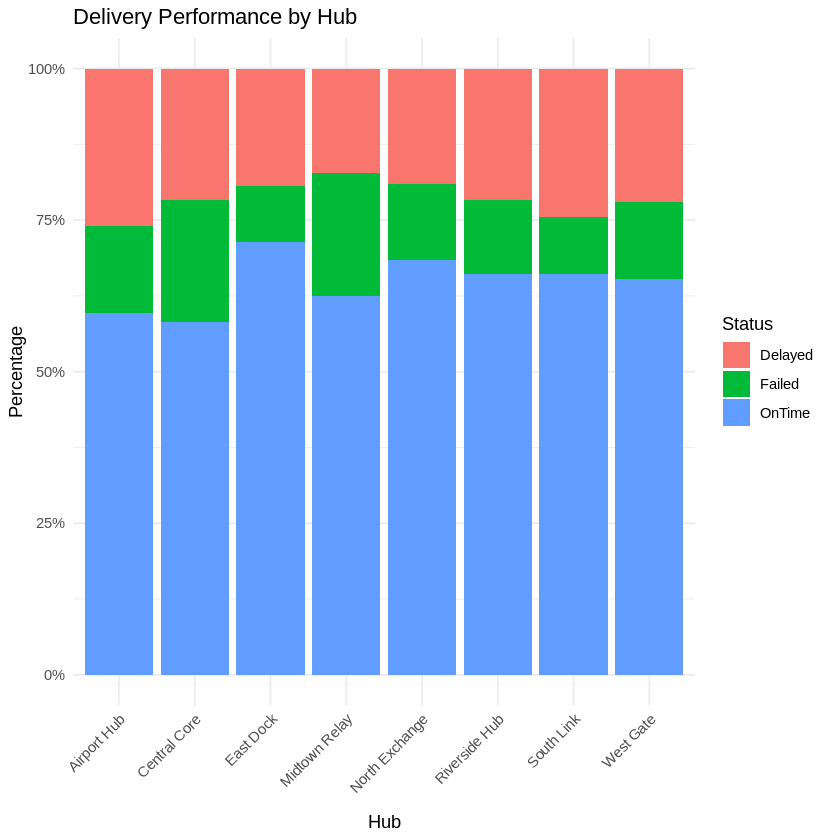

In [ ]:
#DELIVERY STATUS BY HUB
del_hub <- merge(deliveries, hubs, by = "hub_id")

ggplot(del_hub, aes(x = hub_name, fill = delivery_status)) +
  geom_bar(position = "fill") +
  scale_y_continuous(labels = scales::percent) +
  labs(title = "Delivery Performance by Hub",
       x = "Hub",
       y = "Percentage",
       fill = "Status") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

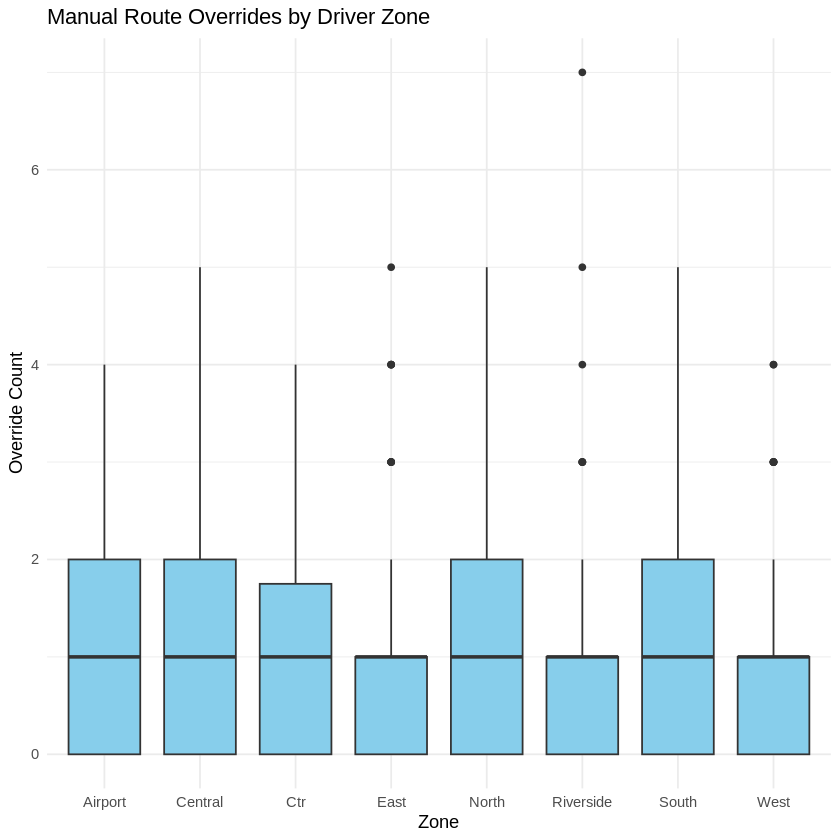

In [ ]:
#ROUTE OVERRIDES BY DRIVER ZONE
del_driver <- merge(deliveries, drivers, by = "driver_id")

ggplot(del_driver, aes(x = base_zone, y = manual_route_override_count)) +
  geom_boxplot(fill = "skyblue") +
  labs(title = "Manual Route Overrides by Driver Zone",
       x = "Zone",
       y = "Override Count") +
  theme_minimal()

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


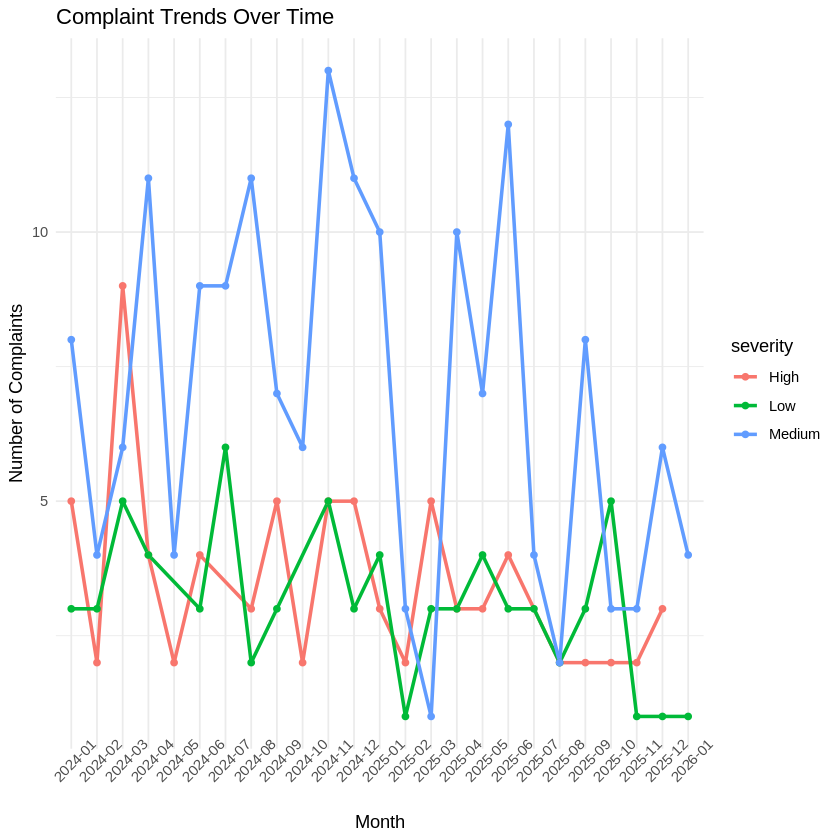

In [ ]:
#COMPLAINT TREND OVER TIME
complaints$created_at <- as.Date(complaints$created_at)

complaints$month <- format(complaints$created_at, "%Y-%m")

comp_trend <- complaints %>%
  group_by(month, severity) %>%
  summarise(count = n(), .groups = "drop")

ggplot(comp_trend, aes(x = month, y = count, color = severity, group = severity)) +
  geom_line(size = 1) +
  geom_point() +
  labs(title = "Complaint Trends Over Time",
       x = "Month",
       y = "Number of Complaints") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45))

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 14 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 14 rows containing missing values or values outside the scale range
(`geom_point()`).”


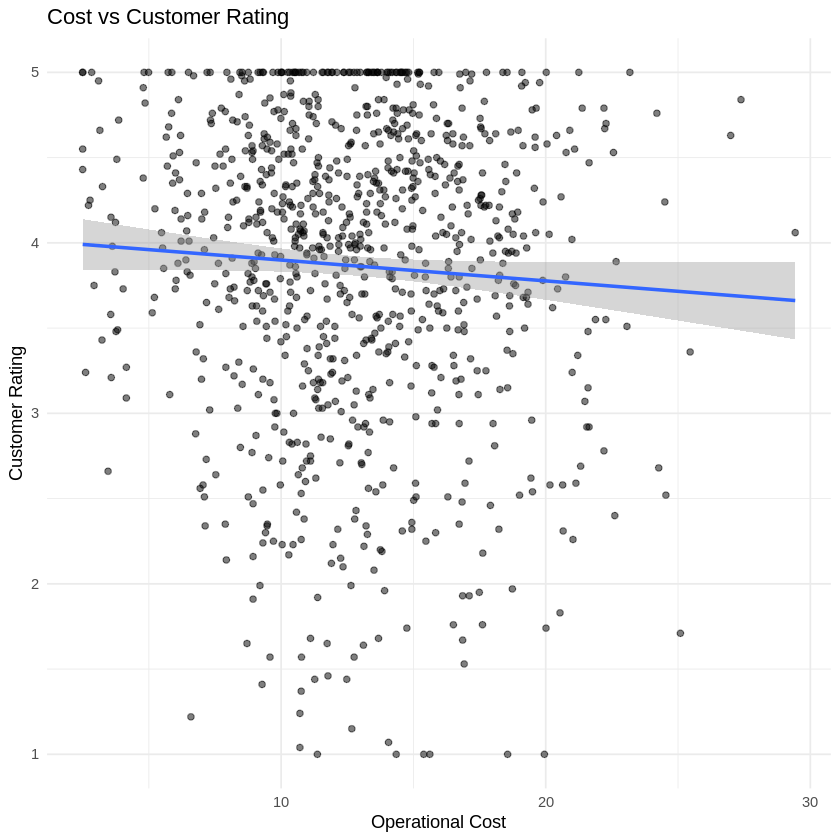

In [ ]:
#CUSTOMER RATING VS DELIVERY COST
del_cost <- merge(deliveries, orders, by = "order_id")

ggplot(del_cost, aes(x = fuel_or_charge_cost, y = customer_rating_post_delivery)) +
  geom_point(alpha = 0.5) +
  geom_smooth(method = "lm") +
  labs(title = "Cost vs Customer Rating",
       x = "Operational Cost",
       y = "Customer Rating") +
  theme_minimal()

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 39 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 39 rows containing missing values or values outside the scale range
(`geom_point()`).”


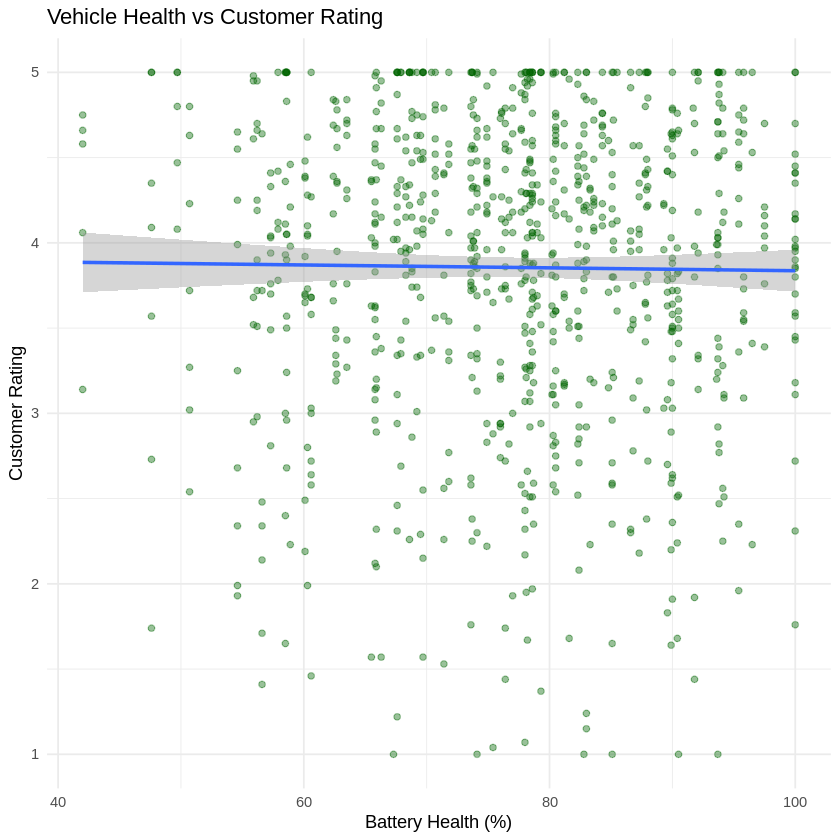

In [ ]:
#VEHICLE HEALTH VS INCIDENTS
del_veh <- merge(deliveries, vehicles, by = "vehicle_id")

ggplot(del_veh, aes(x = battery_health_pct, y = customer_rating_post_delivery)) +
  geom_point(alpha = 0.4, color = "darkgreen") +
  geom_smooth(method = "lm") +
  labs(title = "Vehicle Health vs Customer Rating",
       x = "Battery Health (%)",
       y = "Customer Rating") +
  theme_minimal()
